In [10]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import importlib
import pandas as pd
from datetime import datetime
from tqdm import tqdm
from plotly.subplots import make_subplots
from plotly import tools
import plotly.offline as pyo
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import glob
from scipy import stats
import uproot
from ROOT import TFile, TEfficiency, TH1D, TGraphAsymmErrors, RDataFrame, TCanvas

In [11]:
file = uproot.open('/Users/danielcarber/Documents/ICARUS/eff_mc.root')
print(file.keys())

['events;1', 'events/mc;1', 'events/mc/POT;3', 'events/mc/POT;2', 'events/mc/POT;1', 'events/mc/Livetime;3', 'events/mc/Livetime;2', 'events/mc/Livetime;1', 'events/mc/SelectedNu_Cuts;1', 'events/mc/SelectedCos_PhaseCuts;1', 'events/mc/Efficiency_PhaseCuts;1']


In [12]:
mc_df = file['events/mc/Efficiency_PhaseCuts;1']
mc_df=mc_df.arrays(library='pd')



print(mc_df.keys())


Index(['all_1eNp_cut', 'category_topology', 'fiducial_cut', 'flash_cut',
       'nu_id', 'reco_electrom_pT_mag', 'reco_electron_axial_spread',
       'reco_electron_conv_dist', 'reco_electron_dir_spread',
       'reco_electron_energy', 'reco_proton_energy',
       'reco_proton_muon_softmax', 'reco_proton_pion_softmax',
       'reco_proton_softmax', 'track_containment_cut', 'true_electrom_pT_mag',
       'true_electron_energy', 'true_proton_energy', 'Run', 'Subrun', 'Evt'],
      dtype='object')


In [13]:
quality_cuts = (mc_df['category_topology']==0)|(mc_df['category_topology']==1)
signal = mc_df[quality_cuts]
#mask  = (signal['track_containment_cut']==1)
signal = signal

efficiency = len(signal)/(len(mc_df[quality_cuts]))
print(f"Eff of Containment: {efficiency*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df[quality_cuts])}")

Eff of Containment: 100.00%
Number of Signal and Total: 1492, 1492


In [14]:
def get_eff_bins(df,df_cut,variable ,bins = [0,1000,1]):
    step = 0
    eff_bins,var_bins = [],[]
    while step+bins[0] < bins[1]:
        mask = (df[variable] >=bins[0]+step) & (df[variable] <bins[0]+step+bins[2])
        mask_cut = (df_cut[variable] >=bins[0]+step) & (df_cut[variable] <bins[0]+step+bins[2])
        num_bin = sum(mask_cut)
        den_bin = sum(mask)
        if den_bin == 0:
            eff_bins.append(None)
        else:
            eff_bins.append(num_bin/den_bin)
        var_bins.append(bins[0]+step+(bins[2]/2))
        step += bins[2]
    return eff_bins, var_bins

In [15]:
def cut_eff_bins(df,df_cut,variable ,bins = [0,1000,1]):
    step = 0
    eff_bins,var_bins = [],[]
    while step+bins[0] < bins[1]:
        mask = (df[variable] >=bins[0]+step) & (df[variable] <bins[0]+step+bins[2])
        mask_cut = (df_cut[variable] >=bins[0]+step) & (df_cut[variable] <bins[0]+step+bins[2])
        num_bin = sum(mask_cut)
        den_bin = sum(mask)
        if den_bin == 0:
            eff_bins.append(None)
        else:
            eff_bins.append(num_bin/den_bin)
        var_bins.append(bins[0]+step+(bins[2]/2))
        step += bins[2]
    return eff_bins, var_bins

In [16]:
signal_mask  = (mc_df['category_topology']==0) | (mc_df['category_topology']==1)
signal = mc_df[signal_mask]


mask  = (signal['track_containment_cut']==1)
cut_containment = signal[mask]
mask = (signal['track_containment_cut']==1)&(signal['fiducial_cut']==1)
cut_fiducial = signal[mask]
mask = (signal['track_containment_cut']==1)&(signal['fiducial_cut']==1)&(signal['flash_cut']==1)
cut_flash = signal[mask]
mask  = (signal['all_1eNp_cut']==1)
print(sum(mask))
cut_final_state = signal[mask]
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02)

cut_axial = signal[mask] 
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02) &\
        (signal['reco_electron_dir_spread'] < 0.25)
cut_dir = signal[mask]
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02) &\
        (signal['reco_electron_dir_spread'] < 0.25) & (signal['reco_electron_conv_dist'] < 7.5)
cut_conv = signal[mask]
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02) &\
        (signal['reco_electron_dir_spread'] < 0.25) & (signal['reco_electron_conv_dist'] < 7.5)&\
        (signal['reco_proton_softmax'] >0.6)
cut_proton = signal[mask]
mask  = (signal['all_1eNp_cut']==1) & (signal['reco_electron_axial_spread'] > 0.02) &\
        (signal['reco_electron_dir_spread'] < 0.25) & (signal['reco_electron_conv_dist'] < 7.5)&\
        (signal['reco_proton_softmax'] >0.6) & (signal['reco_proton_muon_softmax'] <0.04)
cut_muon = signal[mask]

1107


Purity of Proton's Muon Softmax < 0,04: 100.00%
Number of Signal and Total: 1492, 1492


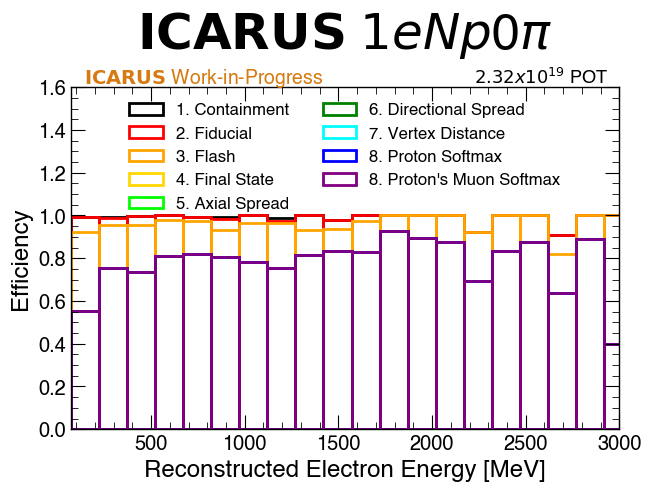

In [17]:
plt.style.use('styles/muon2024_colorswap.mplstyle')


variable = "reco_electron_energy"
bins = [70,3000,150]
eff, var = get_eff_bins(signal,cut_containment,variable,bins = bins)
widths = [bins[2]]*len(eff)
plt.bar(var, eff, width=widths, align='center', edgecolor='black',facecolor='none',label='1. Containment')

eff, var = get_eff_bins(signal,cut_fiducial,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='red',facecolor='none',label='2. Fiducial')
eff, var = get_eff_bins(signal,cut_flash,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='orange',facecolor='none',label='3. Flash')
eff, var = get_eff_bins(signal,cut_final_state,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='gold',facecolor='none',label='4. Final State')
eff, var = get_eff_bins(signal,cut_axial,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='lime',facecolor='none',label='5. Axial Spread')
eff, var = get_eff_bins(signal,cut_dir,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='green',facecolor='none',label='6. Directional Spread')
eff, var = get_eff_bins(signal,cut_conv,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='cyan',facecolor='none',label='7. Vertex Distance')
eff, var = get_eff_bins(signal,cut_proton,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='blue',facecolor='none',label='8. Proton Softmax')
eff, var = get_eff_bins(signal,cut_muon,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='purple',facecolor='none',label="8. Proton's Muon Softmax")

plt.xlabel("Reconstructed Electron Energy [MeV]")
plt.ylabel("Efficiency")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
plt.ylim(0, 1.6)
yrange = [0,1.6]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

plt.legend(ncol=2)
#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Reco_electron_energy_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

In [ ]:
plt.style.use('styles/muon2024_colorswap.mplstyle')


variable = "reco_proton_energy"
bins = [70,3000,150]
eff, var = get_eff_bins(signal,cut_containment,variable,bins = bins)
widths = [bins[2]]*len(eff)
plt.bar(var, eff, width=widths, align='center', edgecolor='black',facecolor='none',label='1. Containment')

eff, var = get_eff_bins(signal,cut_fiducial,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='red',facecolor='none',label='2. Fiducial')
eff, var = get_eff_bins(signal,cut_flash,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='orange',facecolor='none',label='3. Flash')
eff, var = get_eff_bins(signal,cut_final_state,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='gold',facecolor='none',label='4. Final State')
eff, var = get_eff_bins(signal,cut_axial,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='lime',facecolor='none',label='5. Axial Spread')
eff, var = get_eff_bins(signal,cut_dir,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='green',facecolor='none',label='6. Directional Spread')
eff, var = get_eff_bins(signal,cut_conv,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='cyan',facecolor='none',label='7. Vertex Distance')
eff, var = get_eff_bins(signal,cut_proton,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='blue',facecolor='none',label='8. Proton Softmax')
eff, var = get_eff_bins(signal,cut_muon,variable,bins = bins)
plt.bar(var, eff, width=widths, align='center', edgecolor='purple',facecolor='none',label="8. Proton's Muon Softmax")

plt.xlabel("Reconstructed Electron Energy [MeV]")
plt.ylabel("Efficiency")
plt.title(r"$\bf{ICARUS}$ $1eNp$0$\pi$")
plt.xlim(bins[0], bins[1])
plt.ylim(0, 1.6)
yrange = [0,1.6]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [bins[0],bins[1]]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{ICARUS}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$2.32x10^{19}$ POT", fontsize=13, color='black', horizontalalignment='right')

# Set legend
#plt.legend(handles_reordered, labels_reordered)

plt.legend(ncol=2)
#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Reco_proton_energy_eff.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")